# Tensorflow2.0 小练习

In [1]:
import tensorflow as tf
import numpy as np

## 实现softmax函数

In [2]:
def softmax(x):
    ##########
    '''实现softmax函数，只要求对最后一维归一化，
    不允许用tf自带的softmax函数'''
    ##########
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    x_max = tf.reduce_max(x, axis=-1, keepdims=True)
    x_exp = tf.exp(x - x_max)
    prob_x = x_exp / tf.reduce_sum(x_exp, axis=-1, keepdims=True)
    return prob_x

test_data = np.random.normal(size=[10, 5])
(softmax(test_data).numpy() - tf.nn.softmax(test_data, axis=-1).numpy())**2 <0.0001

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

## 实现sigmoid函数

In [3]:
def sigmoid(x):
    ##########
    '''实现sigmoid函数， 不允许用tf自带的sigmoid函数'''
    ##########
    x = tf.convert_to_tensor(x)
    prob_x = 1.0 / (1.0 + tf.exp(-x))

    return prob_x

test_data = np.random.normal(size=[10, 5])
(sigmoid(test_data).numpy() - tf.nn.sigmoid(test_data).numpy())**2 < 0.0001

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

## 实现 softmax 交叉熵loss函数

In [4]:
def softmax_ce(x, label):
    ##########
    '''实现 softmax 交叉熵loss函数， 不允许用tf自带的softmax_cross_entropy函数'''
    ##########
    x = tf.convert_to_tensor(x)
    label = tf.convert_to_tensor(label, dtype=x.dtype)
    eps = tf.cast(1e-12, x.dtype)
    loss = -tf.reduce_mean(tf.reduce_sum(label * tf.math.log(x + eps), axis=-1))
    return loss

test_data = np.random.normal(size=[10, 5])
prob = tf.nn.softmax(test_data)
label = np.zeros_like(test_data)
label[np.arange(10), np.random.randint(0, 5, size=10)]=1.

((tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(label, test_data))
  - softmax_ce(prob, label))**2 < 0.0001).numpy()

True

## 实现 sigmoid 交叉熵loss函数

In [5]:
def sigmoid_ce(x, label):
    ##########
    '''实现 sigmoid 交叉熵loss函数， 不允许用tf自带的sigmoid_cross_entropy函数'''
    ##########
    x = tf.convert_to_tensor(x)
    label = tf.convert_to_tensor(label, dtype=x.dtype)
    eps = tf.cast(1e-12, x.dtype)
    loss = -tf.reduce_mean(label * tf.math.log(x + eps) + (1.0 - label) * tf.math.log(1.0 - x + eps))
    return loss

test_data = np.random.normal(size=[10])
prob = tf.nn.sigmoid(test_data)
label = np.random.randint(0, 2, 10).astype(test_data.dtype)
print (label)

((tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(label, test_data))- sigmoid_ce(prob, label))**2 < 0.0001).numpy()


[1. 1. 0. 1. 1. 0. 0. 0. 1. 0.]


True

## 函数拟合（PyTorch + ReLU）

目标：自定义一个连续函数，在其定义域上采样训练集与测试集，使用两层 ReLU 网络进行拟合并验证效果。

Epoch [500/3000], Train MSE: 0.007223
Epoch [1000/3000], Train MSE: 0.002031
Epoch [1500/3000], Train MSE: 0.000363
Epoch [2000/3000], Train MSE: 0.000115
Epoch [2500/3000], Train MSE: 0.000073
Epoch [3000/3000], Train MSE: 0.000060
Test MSE: 0.000062


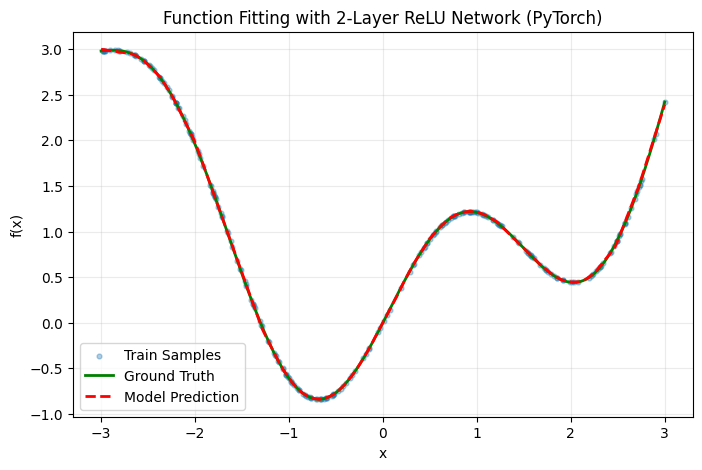

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 固定随机种子，保证结果可复现
torch.manual_seed(42)

# 1) 自定义目标函数：f(x) = sin(2x) + 0.3x^2
def target_function(x):
    return torch.sin(2 * x) + 0.3 * x ** 2

# 2) 在区间 [-3, 3] 采样训练集和测试集
n_train, n_test = 256, 256
x_train = -3 + 6 * torch.rand(n_train, 1)
x_test = torch.linspace(-3, 3, n_test).unsqueeze(1)
y_train = target_function(x_train)
y_test = target_function(x_test)

# 3) 定义两层 ReLU 网络
model = nn.Sequential(
    nn.Linear(1, 64),#输入
    nn.ReLU(),
    nn.Linear(64, 64),#hideden
    nn.ReLU(),
    nn.Linear(64, 1),#输出
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4) 训练模型
epochs = 3000
for epoch in range(epochs):
    pred = model(x_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Train MSE: {loss.item():.6f}")

# 5) 测试集评估
model.eval()
with torch.no_grad():
    y_pred = model(x_test)
    test_mse = criterion(y_pred, y_test).item()

print(f"Test MSE: {test_mse:.6f}")

# 6) 可视化拟合效果
plt.figure(figsize=(8, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=12, alpha=0.35, label='Train Samples')
plt.plot(x_test.numpy(), y_test.numpy(), 'g-', linewidth=2, label='Ground Truth')
plt.plot(x_test.numpy(), y_pred.numpy(), 'r--', linewidth=2, label='Model Prediction')
plt.title('Function Fitting with 2-Layer ReLU Network (PyTorch)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()